In [232]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [233]:
df=pd.read_csv('HR_comma_sep.csv')

In [234]:
df.shape

(14999, 10)

In [235]:
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [236]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   sales                  14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


In [237]:
df.isnull().sum()

,0
satisfaction_level,0
last_evaluation,0
number_project,0
average_montly_hours,0
time_spend_company,0
Work_accident,0
left,0
promotion_last_5years,0
sales,0
salary,0


No missing value in the data

In [238]:
df['sales'].value_counts()

,count
sales,
sales,4140
technical,2720
support,2229
IT,1227
product_mng,902
marketing,858
RandD,787
accounting,767
hr,739


Incorrect Column naming

In [239]:
# Rename the sales column with department and drop sales
df['Department']=df['sales']
df.drop(['sales'],axis=1,inplace=True)

In [240]:
df.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident', 'left',
       'promotion_last_5years', 'salary', 'Department'],
      dtype='object')

In [241]:
#Split the data into numerical and categorical
df_numeric=df.select_dtypes(exclude='object')
df_cat=df.select_dtypes(include='object')


## 2.1. Draw a heatmap of the Correlation Matrix between all numerical features/columns in the data

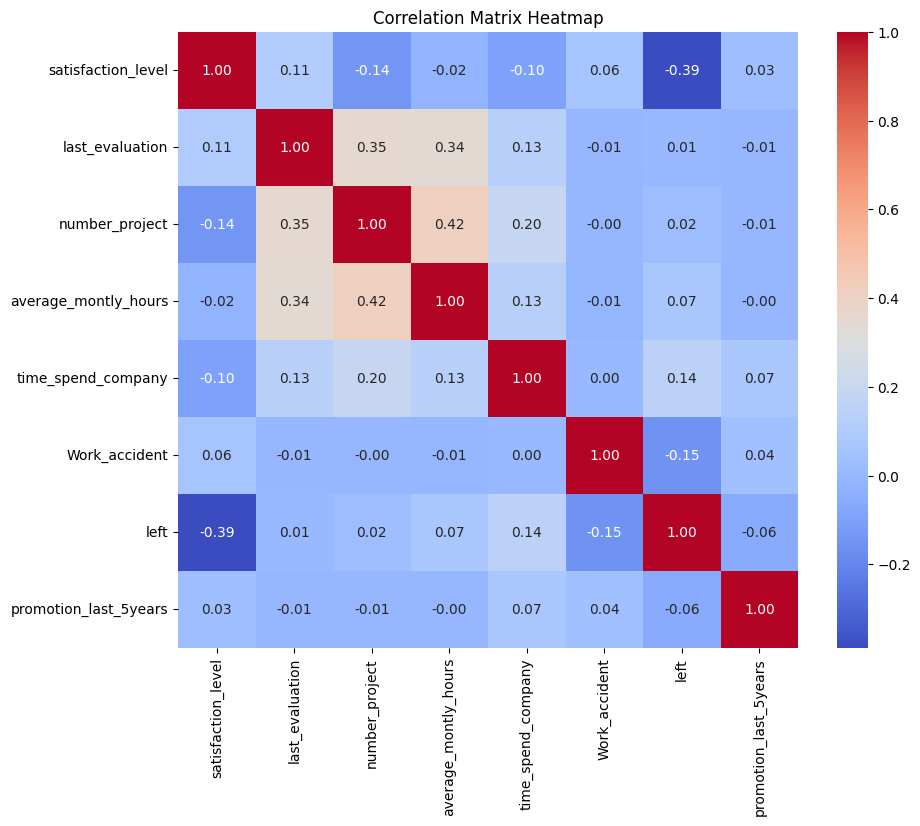

In [242]:
plt.figure(figsize=(10,8))
sns.heatmap(df_numeric.corr(),annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix Heatmap')
plt.show()


# 2.2 Draw the distribution plot of:
            ▪ Employee Satisfaction (use column satisfaction_level)
            ▪ Employee Evaluation (use column last_evaluation)
            ▪ Employee Average Monthly Hours (use column average_montly_hours)

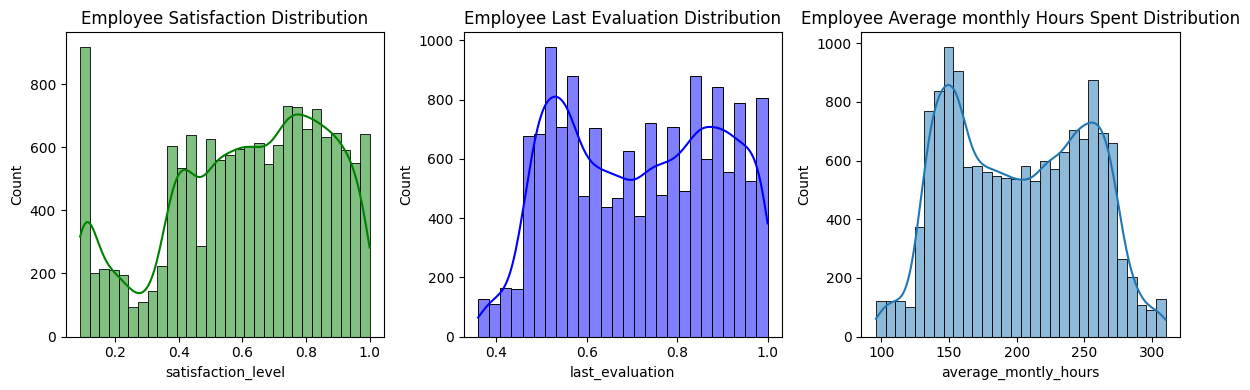

In [243]:
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
sns.histplot(df['satisfaction_level'],kde=True,color='green')
plt.title('Employee Satisfaction Distribution')

plt.subplot(1,3,2)
sns.histplot(df['last_evaluation'],kde=True,color='blue')
plt.title('Employee Last Evaluation Distribution')

plt.subplot(1,3,3)
sns.histplot(df['average_montly_hours'],kde=True)
plt.title('Employee Average monthly Hours Spent Distribution')

plt.tight_layout()
plt.show()

## 2.3 Draw the bar plot of the employee project count of both employees who left and stayed in the organization

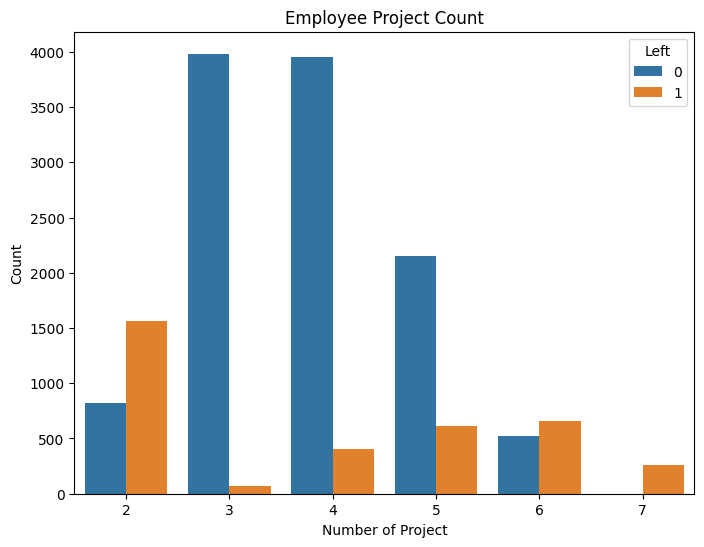

In [244]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df,x='number_project',hue='left')

plt.title('Employee Project Count')
plt.xlabel('Number of Project')
plt.ylabel('Count')
plt.legend(title='Left')
plt.show()

# 2.4. Draw bar plots for categorical columns: Department and salary

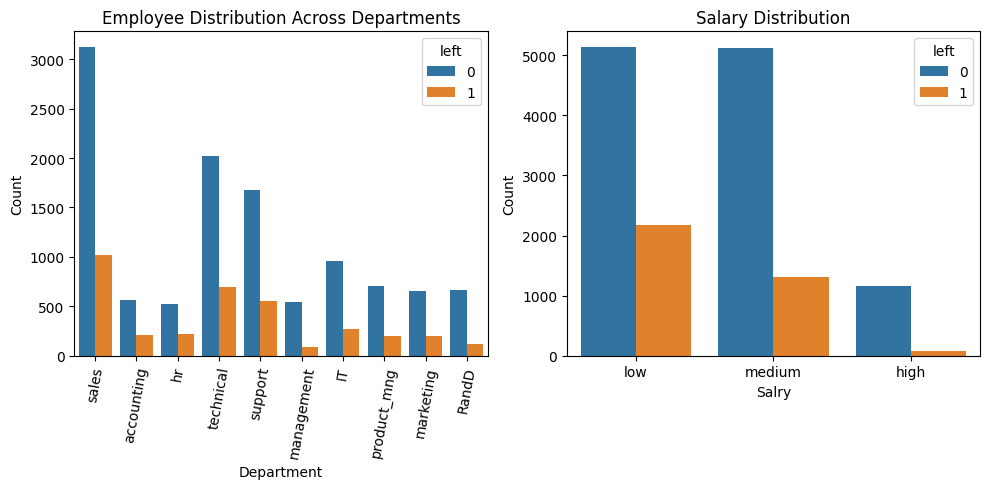

In [245]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sns.countplot(data=df,x='Department',hue='left')
plt.title('Employee Distribution Across Departments')
plt.xlabel('Department')
plt.ylabel('Count')
plt.xticks(rotation=80)  # Rotate x-axis labels for better visibility

plt.subplot(1,2,2)
sns.countplot(data=df,x='salary',hue='left')
plt.title('Salary Distribution')
plt.xlabel('Salry')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

In [246]:
df.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident', 'left',
       'promotion_last_5years', 'salary', 'Department'],
      dtype='object')

In [247]:
df['Department'].unique()

array(['sales', 'accounting', 'hr', 'technical', 'support', 'management',
       'IT', 'product_mng', 'marketing', 'RandD'], dtype=object)

In [248]:
df['Work_accident'].unique()

array([0, 1])

In [249]:
df['left'].unique()

array([1, 0])

In [250]:
df['number_project'].unique()

array([2, 5, 7, 6, 4, 3])

In [251]:
df['promotion_last_5years'].unique()

array([0, 1])

In [252]:
df['salary'].unique()

array(['low', 'medium', 'high'], dtype=object)

In [253]:
df['time_spend_company'].unique()

array([ 3,  6,  4,  5,  2,  8, 10,  7])

In [254]:
df['average_montly_hours'].unique()

array([157, 262, 272, 223, 159, 153, 247, 259, 224, 142, 135, 305, 234,
       148, 137, 143, 160, 255, 282, 147, 304, 139, 158, 242, 239, 128,
       132, 294, 134, 145, 140, 246, 126, 306, 152, 269, 127, 281, 276,
       182, 273, 307, 309, 225, 226, 308, 244, 286, 161, 264, 277, 275,
       149, 295, 151, 249, 291, 232, 130, 129, 155, 265, 279, 284, 221,
       154, 150, 267, 257, 177, 144, 289, 258, 263, 251, 133, 216, 300,
       138, 260, 183, 250, 292, 283, 245, 256, 278, 240, 136, 301, 243,
       296, 274, 164, 146, 261, 285, 141, 297, 156, 287, 219, 254, 228,
       131, 252, 236, 270, 298, 192, 248, 266, 238, 229, 233, 268, 231,
       253, 302, 271, 290, 235, 293, 241, 218, 199, 180, 195, 237, 227,
       172, 206, 181, 217, 310, 214, 198, 211, 222, 213, 202, 184, 204,
       288, 220, 299, 303, 212, 196, 179, 205, 230, 203, 280, 169, 188,
       178, 175, 166, 163, 168, 165, 189, 162, 215, 193, 176, 191, 174,
       201, 208, 171, 111, 104, 106, 100, 194, 209, 185, 200, 20

In [255]:
df['satisfaction_level'].unique()

array([0.38, 0.8 , 0.11, 0.72, 0.37, 0.41, 0.1 , 0.92, 0.89, 0.42, 0.45,
       0.84, 0.36, 0.78, 0.76, 0.09, 0.46, 0.4 , 0.82, 0.87, 0.57, 0.43,
       0.13, 0.44, 0.39, 0.85, 0.81, 0.9 , 0.74, 0.79, 0.17, 0.24, 0.91,
       0.71, 0.86, 0.14, 0.75, 0.7 , 0.31, 0.73, 0.83, 0.32, 0.54, 0.27,
       0.77, 0.88, 0.48, 0.19, 0.6 , 0.12, 0.61, 0.33, 0.56, 0.47, 0.28,
       0.55, 0.53, 0.59, 0.66, 0.25, 0.34, 0.58, 0.51, 0.35, 0.64, 0.5 ,
       0.23, 0.15, 0.49, 0.3 , 0.63, 0.21, 0.62, 0.29, 0.2 , 0.16, 0.65,
       0.68, 0.67, 0.22, 0.26, 0.99, 0.98, 1.  , 0.52, 0.93, 0.97, 0.69,
       0.94, 0.96, 0.18, 0.95])

In [256]:
df['last_evaluation'].unique()

array([0.53, 0.86, 0.88, 0.87, 0.52, 0.5 , 0.77, 0.85, 1.  , 0.54, 0.81,
       0.92, 0.55, 0.56, 0.47, 0.99, 0.51, 0.89, 0.83, 0.95, 0.57, 0.49,
       0.46, 0.62, 0.94, 0.48, 0.8 , 0.74, 0.7 , 0.78, 0.91, 0.93, 0.98,
       0.97, 0.79, 0.59, 0.84, 0.45, 0.96, 0.68, 0.82, 0.9 , 0.71, 0.6 ,
       0.65, 0.58, 0.72, 0.67, 0.75, 0.73, 0.63, 0.61, 0.76, 0.66, 0.69,
       0.37, 0.64, 0.39, 0.41, 0.43, 0.44, 0.36, 0.38, 0.4 , 0.42])

#3. Perform clustering of employees who left based on their satisfaction and evaluation
3.1. Choose columns satisfaction_level, last_evaluation and left
3.2. Do K-Means clustering of employees who left the company into 3 clusters?
3.3. Based on the satisfaction and evaluation factors, give your thoughts on the employee clusters

In [257]:
import warnings
warnings.filterwarnings('ignore')

In [258]:
# Select columns
df1=df[['satisfaction_level','last_evaluation','left']].copy()

In [259]:
#Filter out the data for those employees who left the company:
df1_left=df1[df1['left']==1]
df1_left

,satisfaction_level,last_evaluation,left
0,0.38,0.53,1
1,0.80,0.86,1
2,0.11,0.88,1
3,0.72,0.87,1
4,0.37,0.52,1
...,...,...,...
14994,0.40,0.57,1
14995,0.37,0.48,1
14996,0.37,0.53,1
14997,0.11,0.96,1


In [260]:
#drop the left column from df1_left
df1_left.drop('left',axis=1)

,satisfaction_level,last_evaluation
0,0.38,0.53
1,0.80,0.86
2,0.11,0.88
3,0.72,0.87
4,0.37,0.52
...,...,...
14994,0.40,0.57
14995,0.37,0.48
14996,0.37,0.53
14997,0.11,0.96


In [261]:
from sklearn.cluster import KMeans

In [262]:
k_model=KMeans(n_clusters=3, random_state=123)
k_model.fit(df1_left)

KMeans(n_clusters=3, random_state=123)

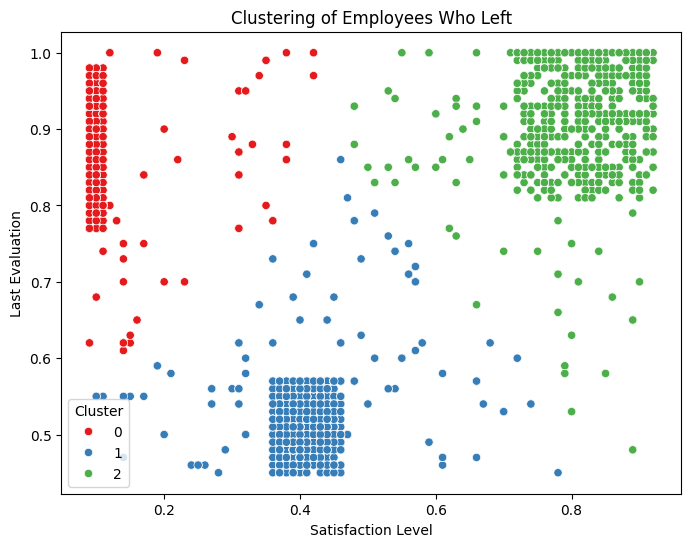

In [263]:
# Add cluster labels to the dataframe
df1_left['cluster'] = k_model.labels_

# Visualize the clusters
plt.figure(figsize=(8, 6))
sns.scatterplot(x='satisfaction_level', y='last_evaluation', hue='cluster', data=df1_left, palette='Set1', legend='full')
plt.title('Clustering of Employees Who Left')
plt.xlabel('Satisfaction Level')
plt.ylabel('Last Evaluation')
plt.legend(title='Cluster')
plt.show()

In [264]:
df1_left['cluster'].value_counts()

,count
cluster,
1,1650
2,977
0,944




*    **Cluster 0** (Satisfaction Level: Low to Medium  ,
Evaluation Score: Low to Medium )
Disengaged and underperforming employees left due to lack of motivation, poor performance, or feeling undervalued.


*   **Cluster 1** (High Satisfaction, High Evaluation)
Successful and satisfied employees left for better career opportunities, lack of promotions, or work-life balance issues.

* **Cluster 2** (Low Satisfaction, High Evaluation)
High-performing but dissatisfied employees left due to burnout, lack of recognition, or feeling underpaid.




In [265]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   salary                 14999 non-null  object 
 9   Department             14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


#4 Handle the left Class Imbalance using the SMOTE technique.
        4.1. Pre-process the data by converting categorical columns to numerical columns by:
            ▪ Separating categorical variables and numeric variables
            ▪ Applying get_dummies() to the categorical variables
            ▪ Combining categorical variables and numeric variables
        4.2. Do the stratified split of the dataset to train and test in the ratio 80:20 with random_state=123.
        4.3. Upsample the train dataset using the SMOTE technique from the imblearn module.

In [266]:
#Applying get_dummies() to the categorical variables
df_cat_dummy=pd.get_dummies(df_cat)
df_cat_dummy.head()

,salary_high,salary_low,salary_medium,Department_IT,Department_RandD,Department_accounting,Department_hr,Department_management,Department_marketing,Department_product_mng,Department_sales,Department_support,Department_technical
0,False,True,False,False,False,False,False,False,False,False,True,False,False
1,False,False,True,False,False,False,False,False,False,False,True,False,False
2,False,False,True,False,False,False,False,False,False,False,True,False,False
3,False,True,False,False,False,False,False,False,False,False,True,False,False
4,False,True,False,False,False,False,False,False,False,False,True,False,False


In [267]:
#Combining categorical variables and numeric variables
df2=pd.concat([df_numeric,df_cat_dummy],axis=1, join='inner')

In [268]:
print(df_numeric.shape)
print(df_cat_dummy.shape)

(14999, 8)
(14999, 13)


In [269]:
df2.shape

(14999, 21)

In [270]:
# Do the stratified split of the dataset to train and test in the ratio 80:20 with random_state=123.
X=df2.drop('left',axis=1)
y=df2['left']

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=123)

In [271]:
y_train.value_counts()

,count
left,
0,9137
1,2862


Data is highly imbalanced as in training data,  the employees who left the company are comparatively very less in count .

Let's use SMOTE technique to handle this imbalance data.

In [272]:
!pip install imblearn

In [273]:
from imblearn.over_sampling import SMOTE

In [274]:
smote=SMOTE(random_state=123)

In [275]:
X_train_resample,y_train_resample=smote.fit_resample(X_train,y_train)

In [276]:
# Checking the new class distribution
print("Original class distribution:\n", y_train.value_counts())
print("Resampled class distribution:\n", y_train_resample.value_counts())

Original class distribution:
 left
0    9137
1    2862
Name: count, dtype: int64
Resampled class distribution:
 left
0    9137
1    9137
Name: count, dtype: int64


#5). Perform 5-fold cross-validation model training and evaluate performance.
        5.1. Train a logistic regression model, apply a 5-fold CV, and plot the classification report.

In [277]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.linear_model import LogisticRegression

In [278]:
#define model
model1=LogisticRegression(solver='lbfgs', max_iter=10000)

#define no. of folds for CV
kf=KFold(n_splits=5, shuffle=True, random_state=123)

# Perform 5-Fold CV to evaluate model performance
score=cross_val_score(model1,X_train_resample,y_train_resample, cv=kf, scoring='accuracy')

In [279]:
print(score.mean())

0.8068843169451689


In [280]:
model1.fit(X_train_resample,y_train_resample)
y_pred_1=model1.predict(X_test)

In [281]:
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score

Logistic Regression Report

In [282]:
print(classification_report(y_test,y_pred_1))

              precision    recall  f1-score   support

           0       0.89      0.80      0.84      2291
           1       0.51      0.68      0.58       709

    accuracy                           0.77      3000
   macro avg       0.70      0.74      0.71      3000
weighted avg       0.80      0.77      0.78      3000



In [283]:
roc_auc_score(y_test,y_pred_1)

0.7387163482050016

[0.         0.19816674 1.        ]
[0.         0.67559944 1.        ]
[inf  1.  0.]
0.7387163482050016


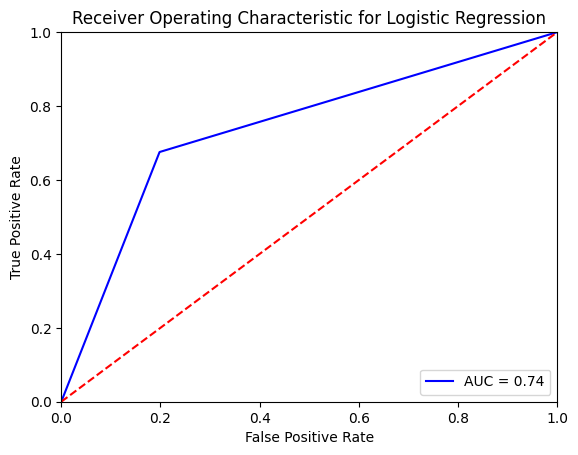

In [284]:
import sklearn.metrics as metrics
fpr,tpr,threshold=metrics.roc_curve(y_test,y_pred_1)
print(fpr)
print(tpr)
print(threshold)
roc_auc = metrics.auc(fpr, tpr)
print(roc_auc)

# method I: plt
plt.title('Receiver Operating Characteristic for Logistic Regression')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

5.2 Train a Random Forest Classifier model, apply the 5-fold CV, and plot the classification report.

In [285]:
from sklearn.ensemble import RandomForestClassifier

#define the model
model2=RandomForestClassifier(n_estimators=40,random_state=123)

#Perform the CV for model performance evaluation
print(cross_val_score(model2, X_train_resample,y_train_resample ,cv=kf, scoring='accuracy').mean())

0.9841303236076575


In [286]:
model2.fit(X_train_resample,y_train_resample)
y_pred_2=model2.predict(X_test)

Random Forest Classification Report

In [287]:
print(classification_report(y_test,y_pred_2))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      2291
           1       0.98      0.97      0.98       709

    accuracy                           0.99      3000
   macro avg       0.99      0.98      0.99      3000
weighted avg       0.99      0.99      0.99      3000



In [288]:
roc_auc_score(y_test,y_pred_2)

0.9846871211874022

[0.         0.00523789 1.        ]
[0.         0.97461213 1.        ]
[inf  1.  0.]
0.9846871211874022


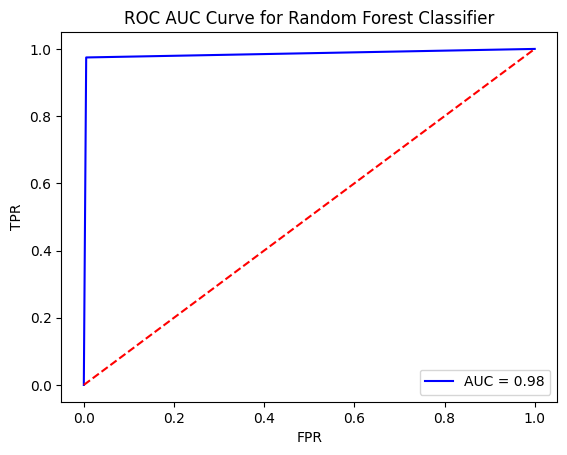

In [289]:
fpr,tpr,threshold=metrics.roc_curve(y_test,y_pred_2)
print(fpr)
print(tpr)
print(threshold)

auc=metrics.auc(fpr,tpr)
print(auc)

plt.plot(fpr,tpr,'b',label='AUC = %0.2f'%auc)
plt.plot([0,1],[0,1],'r--')
plt.legend(loc='lower right')
plt.title('ROC AUC Curve for Random Forest Classifier')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.show()

Gradient Boosting Classifier

In [290]:
from sklearn.ensemble import GradientBoostingClassifier

In [291]:
#define model
model3=GradientBoostingClassifier(n_estimators=100,max_depth=5,random_state=123)

# Perform CV to evaluate model performance
score=cross_val_score(model3,X_train_resample,y_train_resample,cv=kf,scoring='accuracy')

In [292]:
print(score.mean())

0.9747729789590254


In [293]:
#train model
model3.fit(X_train_resample,y_train_resample)
y_pred_3=model3.predict(X_test)

Gradient boosting Classification Report

In [294]:
print(classification_report(y_test,y_pred_3))

              precision    recall  f1-score   support

           0       0.98      0.99      0.98      2291
           1       0.96      0.94      0.95       709

    accuracy                           0.98      3000
   macro avg       0.97      0.97      0.97      3000
weighted avg       0.98      0.98      0.98      3000



In [295]:
roc_auc_score(y_test,y_pred_3)

0.9654621413650891

[0.         0.01265823 1.        ]
[0.         0.97461213 1.        ]
[inf  1.  0.]
0.9809769509560623


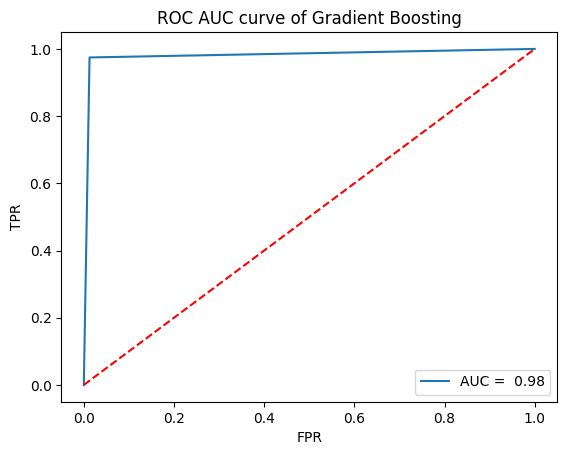

In [296]:
fpr,tp,threshold=metrics.roc_curve(y_test,y_pred_3)
print(fpr)
print(tpr)
print(threshold)

auc=metrics.auc(fpr,tpr)
print(auc)

plt.plot(fpr,tpr,label="AUC = % 0.2f" % auc)
plt.plot([0,1],[0,1],'r--')
plt.legend(loc='lower right')
plt.xlabel("FPR")
plt.ylabel('TPR')
plt.title('ROC AUC curve of Gradient Boosting')
plt.show()

In [297]:
# Apply AdaBoost
from sklearn.ensemble import AdaBoostClassifier
model4=AdaBoostClassifier(n_estimators=70)

In [298]:
model4.fit(X_train_resample,y_train_resample)

AdaBoostClassifier(n_estimators=70)

In [299]:
y_pred_4=model4.predict(X_test)

In [300]:
print(classification_report(y_test,y_pred_4))

              precision    recall  f1-score   support

           0       0.98      0.93      0.95      2291
           1       0.80      0.94      0.86       709

    accuracy                           0.93      3000
   macro avg       0.89      0.93      0.91      3000
weighted avg       0.94      0.93      0.93      3000



In [301]:
!pip install xgboost

In [302]:
import xgboost

In [303]:
from xgboost import XGBClassifier
xgb=XGBClassifier(gamma=50)

In [304]:
xgb.fit(X_train_resample,y_train_resample)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=50, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [305]:
y_pred_5=xgb.predict(X_test)

In [306]:
print(classification_report(y_test,y_pred_5))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      2291
           1       0.94      0.93      0.93       709

    accuracy                           0.97      3000
   macro avg       0.96      0.96      0.96      3000
weighted avg       0.97      0.97      0.97      3000



In [307]:
roc_auc_score(y_test,y_pred_5)

0.9556232488815312

[0.         0.01964208 1.        ]
[0.         0.97461213 1.        ]
[inf  1.  0.]
0.977485026032448


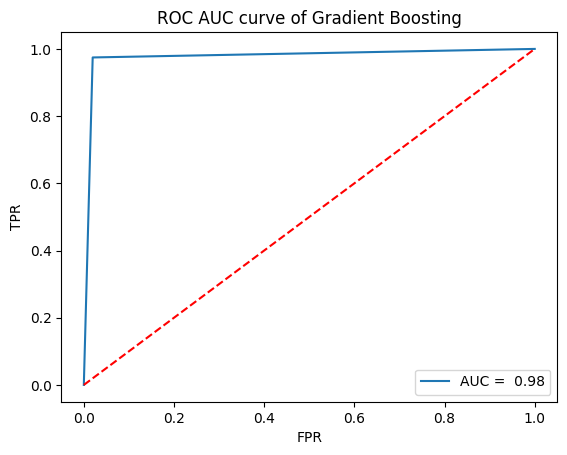

In [308]:
fpr,tp,threshold=metrics.roc_curve(y_test,y_pred_5)
print(fpr)
print(tpr)
print(threshold)

auc=metrics.auc(fpr,tpr)
print(auc)

plt.plot(fpr,tpr,label="AUC = % 0.2f" % auc)
plt.plot([0,1],[0,1],'r--')
plt.legend(loc='lower right')
plt.xlabel("FPR")
plt.ylabel('TPR')
plt.title('ROC AUC curve of Gradient Boosting')
plt.show()

Based on the confusion matrix, the false negatives should be low because if an employee who might leave the organisation is misclassified as someone who won't leave then proper strategies to retain that person will not be implemented on him or her. Hence Recall is better metric to be used.

Since Random Forest shows the highest Recall score with good f1 score, we will conclude that to be our best performing model.

In [309]:
col=X_train_resample.columns
col

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident',
       'promotion_last_5years', 'salary_high', 'salary_low', 'salary_medium',
       'Department_IT', 'Department_RandD', 'Department_accounting',
       'Department_hr', 'Department_management', 'Department_marketing',
       'Department_product_mng', 'Department_sales', 'Department_support',
       'Department_technical'],
      dtype='object')

In [310]:
feature_labels = np.array(col)

In [311]:
importance = model2.feature_importances_
feature_indexes_by_importance = importance.argsort()
for index in feature_indexes_by_importance:
    print('{}-{:.2f}%'.format(feature_labels[index], (importance[index] *100.0)))

Department_product_mng-0.12%
Department_management-0.19%
Department_marketing-0.20%
promotion_last_5years-0.22%
Department_RandD-0.24%
Department_accounting-0.27%
Department_IT-0.28%
Department_hr-0.35%
Department_support-0.57%
Department_sales-0.61%
salary_high-0.73%
Department_technical-0.73%
salary_medium-0.94%
salary_low-1.21%
Work_accident-2.19%
number_project-11.53%
last_evaluation-12.87%
average_montly_hours-15.34%
time_spend_company-23.94%
satisfaction_level-27.45%


The above lists the factors that influences the turnover in the ascending order. It can be identified that the employee turnover is highly influenced by the employee's satisfaction level in the organisation. Improvement of work culture within the organiation can be a good way to prevent the employees from leaving the organisation.

In [325]:
predict_probability = model2.predict_proba(X_test)
predict_probability[:,1]

array([0.   , 0.   , 0.   , ..., 1.   , 0.   , 0.025])

            ▪ Safe Zone (Green) (Score < 20%)
            ▪ Low-Risk Zone (Yellow) (20% < Score < 60%)
            ▪ Medium-Risk Zone (Orange) (60% < Score < 90%)
            ▪ High-Risk Zone (Red) (Score > 90%).


In [326]:

zone=[]
prob=[]

for i in predict_probability[:,1]:
  prob.append(i)
  if (i<=0.2):
    zone.append("Safe Zone")
  elif (i>0.2 and i<=0.6):
    zone.append("Low Risk Zone")
  elif (i>0.6 and i<=0.9):
    zone.append("Medium Risk Zone ")
  else:
    zone.append("High Risk Zone ")


In [327]:
categories = ["Safe Zone","Low Risk Zone","Medium Risk Zone ","High Risk Zone "]
color = ["Green","Yellow","Orange","Red"]

In [328]:
colordict = dict(zip(categories, color))

In [329]:
clr = pd.DataFrame({"zone":zone,"probability":prob})

In [330]:
clr["zone"].unique()

array(['Safe Zone', 'High Risk Zone ', 'Medium Risk Zone ',
       'Low Risk Zone'], dtype=object)

In [331]:
clr["Color"] = clr["zone"].apply(lambda x: colordict[x])

In [332]:
clr.head(10)

,zone,probability,Color
0,Safe Zone,0.00,Green
1,Safe Zone,0.00,Green
2,Safe Zone,0.00,Green
3,Safe Zone,0.20,Green
4,Safe Zone,0.00,Green
5,Safe Zone,0.05,Green
6,High Risk Zone,1.00,Red
7,High Risk Zone,1.00,Red
8,Safe Zone,0.00,Green
9,Safe Zone,0.00,Green


In [333]:
clr['zone'] = clr['zone'].astype(str)

In [334]:
clr['zone'].value_counts()

,count
zone,
Safe Zone,2181
High Risk Zone,644
Low Risk Zone,123
Medium Risk Zone,52


In [322]:
color= clr["Color"].tolist()

In [323]:
c = ["Green","Red","Orange","Yellow"]

<Axes: xlabel='count'>

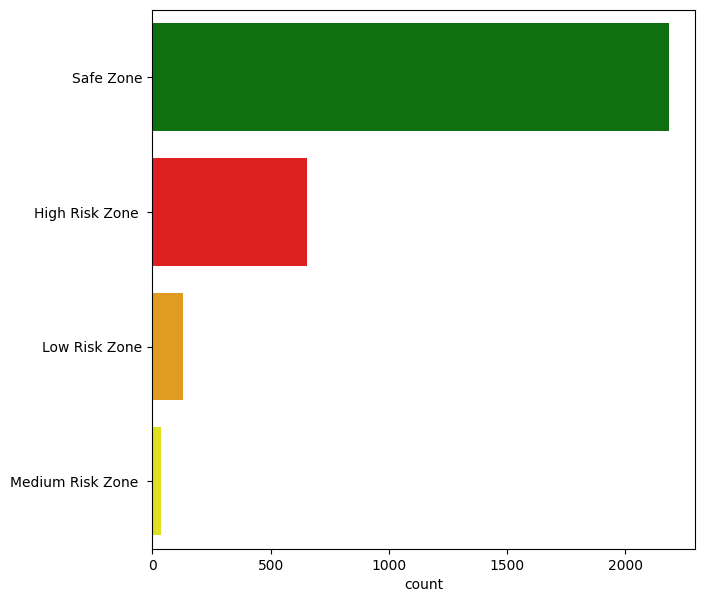

In [324]:
plt.figure(figsize=(7,7))
sns.countplot(zone,palette=c)